# Machine Learning for Business — Week 2
## Classes 3 & 4: Evaluation + Forecasting + Synthesis

**BANA 4373 / ECON 4370 — Dr. Fidel González — Sam Houston State University — Spring 2026**

---

### What this notebook covers

| Class | Topics | Notebook Sections |
|---|---|---|
| **Class 3** | Regression & classification metrics, ROC/AUC, data leakage, time-series ML, Prophet forecasting | Parts 1–9 |
| **Class 4** | Prediction vs. causation synthesis, SHAP explainability, ML fairness, course arc | Parts 10–15 |

### Two datasets

**Part A — Retail demand time series** (Classes 3): Synthetic weekly store sales with planted trend, seasonality, and holiday effects — calibrated to match U.S. retail patterns.

**Part B — Churn model continued** (Class 4): We reload the Week 1 churn model and open its black box with SHAP and fairness slicing.

---

> **Folder structure reminder:** `ROOT/data_raw/` → `data_clean/` → `exports/`

**Student Name:** ___________________________

---
## ⭐ Write Your Prior — Class 3

> **Answer on paper before running any code:**

1. A retailer has 3 years of weekly sales data. You want to train a model to forecast the next 4 weeks. **Describe** how you would split the data. Would you split randomly? Why or why not?

2. You train a Prophet model on 3 years of data. It achieves MAPE = 4% on training data and MAPE = 22% on the test period. What does this tell you? What would you check first?

3. Name **two external features** beyond historical sales that might improve a retail demand forecast. Why would each help?

**Your answers (write before running any Class 3 code):**

1. 

2. 

3. 

---
## 0) Setup

In [ ]:
%pip install shap

In [ ]:
%pip install prophet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error, r2_score,
    roc_auc_score, roc_curve,
    accuracy_score, recall_score, precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed. Run: pip install shap')
    print('Parts 11-12 will be skipped.')

# Prophet
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False
    print('Prophet not installed. Run: pip install prophet')
    print('Parts 7-8 will be skipped.')

# Color palette
NAVY   = '#001F54'
TEAL   = '#006D77'
GOLD   = '#C5A000'
RED    = '#C0392B'
GRAY   = '#7F8C8D'

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'sans-serif'
})

import os
os.makedirs('data_raw',   exist_ok=True)
os.makedirs('data_clean', exist_ok=True)
os.makedirs('exports',    exist_ok=True)

SEED = 42
np.random.seed(SEED)
print('Setup complete.')

Setup complete.


---
## Part 1 — Simulate Retail Weekly Sales Data

We generate 3 years of weekly store sales with **known decomposition components**, so you can verify that Prophet recovers them.

In [4]:
np.random.seed(SEED)

# Date range: 3 years + 4-week forecast horizon
dates = pd.date_range(start='2021-01-04', periods=156+4, freq='W-MON')  # 160 weeks
n     = len(dates)
t     = np.arange(n)

# === PLANTED COMPONENTS ===
# Trend: linear growth (~$200 extra/week per year)
TRUE_TREND = 5000 + 4.0 * t

# Seasonality: annual + holiday
TRUE_SEASONALITY = (
    600  * np.sin(2*np.pi * t / 52)        # annual cycle (peaks in Dec)
    + 200 * np.sin(4*np.pi * t / 52)       # biannual harmonic
    - 300 * np.cos(2*np.pi * t / 52)       # phase shift
)

# Holiday bumps (Thanksgiving week, Christmas week)
thanksgiving_idx = [47, 99, 151]     # ~week 47 each year
christmas_idx    = [51, 103, 155]
TRUE_HOLIDAY = np.zeros(n)
for idx in thanksgiving_idx:
    if idx < n: TRUE_HOLIDAY[idx] = 1800
for idx in christmas_idx:
    if idx < n: TRUE_HOLIDAY[idx] = 2500

# Noise
noise = np.random.normal(0, 250, n)

# Final sales
sales = (TRUE_TREND + TRUE_SEASONALITY + TRUE_HOLIDAY + noise).clip(1000)

ts_df = pd.DataFrame({
    'ds':    dates,
    'y':     sales.round(0),
    'TRUE_TREND':       TRUE_TREND,
    'TRUE_SEASONALITY': TRUE_SEASONALITY + TRUE_HOLIDAY
})

ts_df.to_csv('data_raw/retail_weekly_sales.csv', index=False)

print(f'Weekly sales: {len(ts_df)} weeks | {ts_df.ds.min().date()} → {ts_df.ds.max().date()}')
print(f'Sales range: ${ts_df.y.min():,.0f} – ${ts_df.y.max():,.0f}')
print(f'Mean weekly sales: ${ts_df.y.mean():,.0f}')
ts_df.head()

Weekly sales: 160 weeks | 2021-01-04 → 2024-01-22
Sales range: $3,955 – $7,523
Mean weekly sales: $5,379


,ds,y,TRUE_TREND,TRUE_SEASONALITY
0,2021-01-04,4824.0,5000.0,-300.000000
1,2021-01-11,4792.0,5004.0,-177.627521
2,2021-01-18,5115.0,5008.0,-54.748512
3,2021-01-25,5458.0,5012.0,64.882591
4,2021-02-01,5135.0,5016.0,177.793869


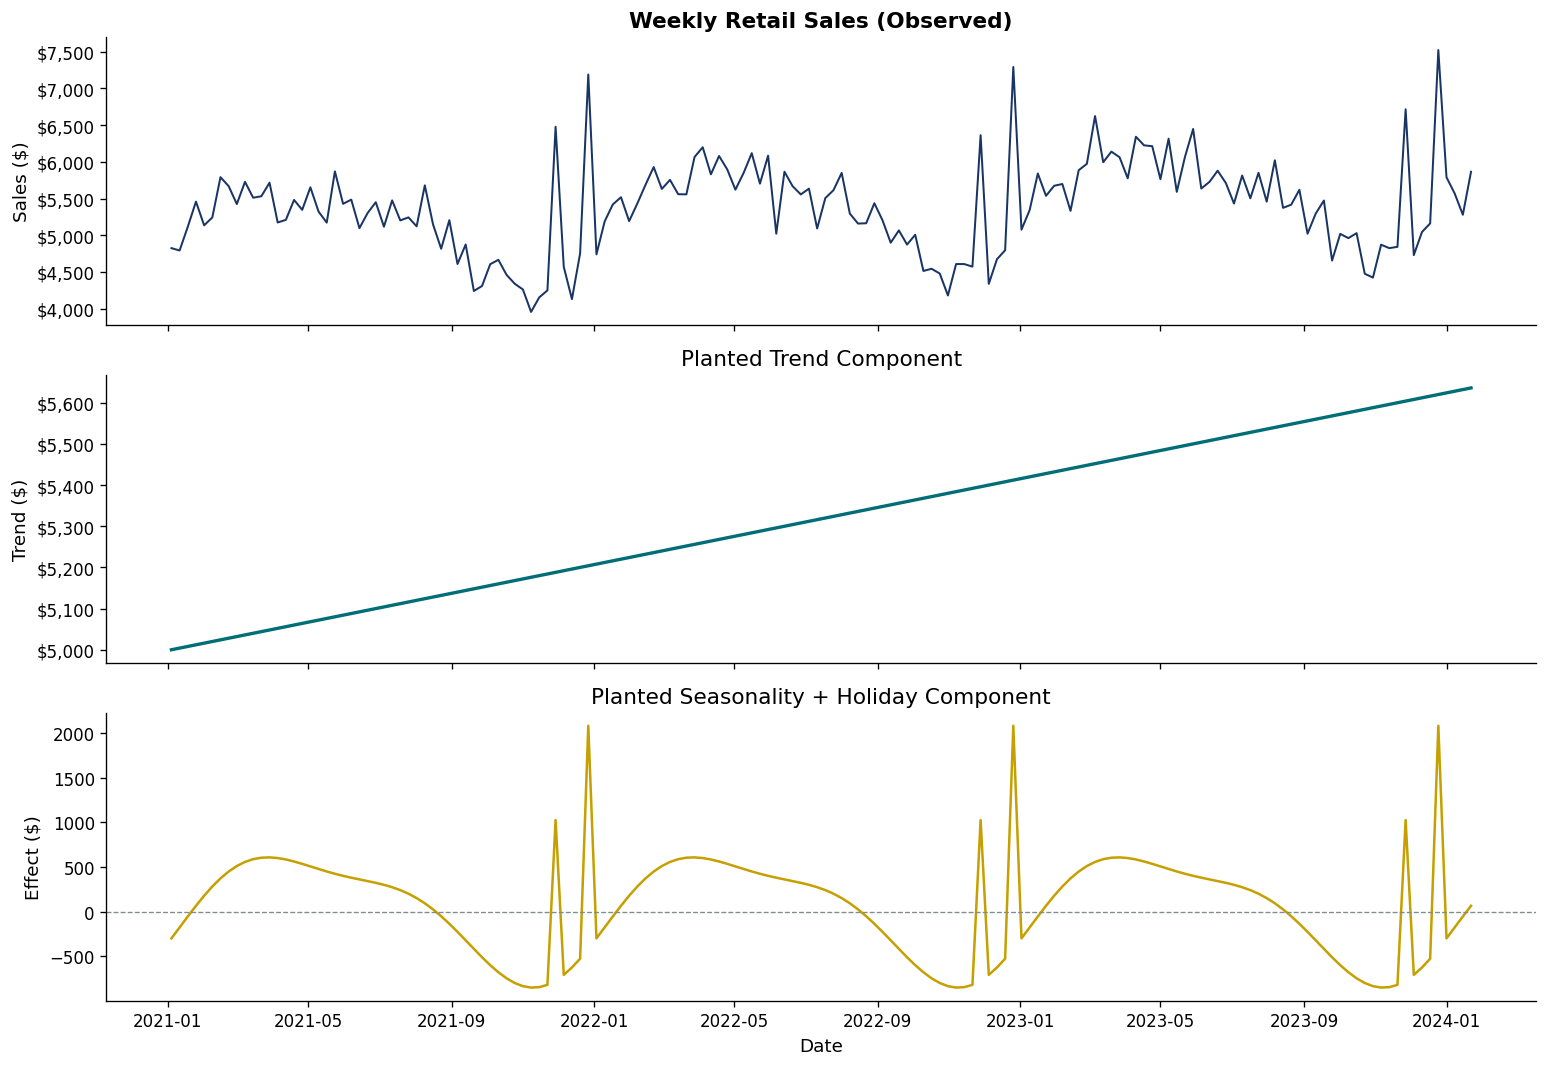

Saved → exports/retail_ts_decomposition.png


In [6]:
# Visualize the time series with components
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(ts_df.ds, ts_df.y, color=NAVY, lw=1.2, alpha=0.9)
axes[0].set_title('Weekly Retail Sales (Observed)', fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].plot(ts_df.ds, ts_df.TRUE_TREND, color=TEAL, lw=2)
axes[1].set_title('Planted Trend Component')
axes[1].set_ylabel('Trend ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[2].plot(ts_df.ds, ts_df.TRUE_SEASONALITY, color=GOLD, lw=1.5)
axes[2].axhline(0, color=GRAY, ls='--', lw=0.8)
axes[2].set_title('Planted Seasonality + Holiday Component')
axes[2].set_ylabel('Effect ($)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig('exports/retail_ts_decomposition.png', bbox_inches='tight')
plt.show()
print('Saved → exports/retail_ts_decomposition.png')

**💬 Interpretation:** Describe what you see in the three panels. What is the rough weekly sales trend per year (look at the planted trend)? When do the holiday spikes appear?

---
## Part 2 — Chronological Train/Test Split

> **⚠️ Never shuffle time series data.** Always split chronologically.

Training period:  2021-01-04 → 2023-12-25  (156 weeks)
Test period:      2024-01-01  → 2024-01-22   (4 weeks)


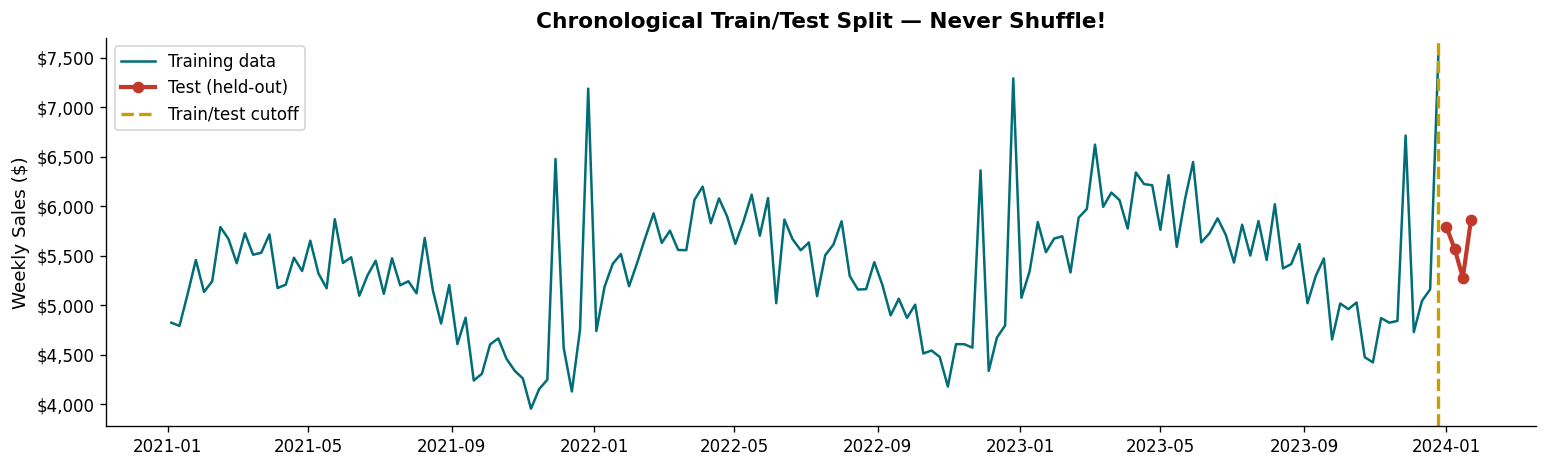

In [8]:
# Hold out last 4 weeks as test (the 'forecast horizon')
FORECAST_HORIZON = 4

train_ts = ts_df.iloc[:-FORECAST_HORIZON].copy()
test_ts  = ts_df.iloc[-FORECAST_HORIZON:].copy()

print(f'Training period:  {train_ts.ds.min().date()} → {train_ts.ds.max().date()}  ({len(train_ts)} weeks)')
print(f'Test period:      {test_ts.ds.min().date()}  → {test_ts.ds.max().date()}   ({len(test_ts)} weeks)')

# Visualize the split
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_ts.ds, train_ts.y, color=TEAL, lw=1.5, label='Training data')
ax.plot(test_ts.ds,  test_ts.y,  color=RED,  lw=2.5, marker='o', markersize=6, label='Test (held-out)')
ax.axvline(train_ts.ds.max(), color=GOLD, ls='--', lw=2, label='Train/test cutoff')
ax.set_title('Chronological Train/Test Split — Never Shuffle!', fontweight='bold')
ax.set_ylabel('Weekly Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('exports/ts_train_test_split.png', bbox_inches='tight')
plt.show()

**💬 Why must we NOT shuffle this data for the split?** Explain what would happen to the model's error estimate if we randomly shuffled and split.

---
## Part 3 — Naive Benchmark Model

Before any ML: what does the simplest possible forecast look like?

In [10]:
# Naive seasonal benchmark: use the same week from last year
# (equivalent to a lag-52 forecast)
naive_forecast = train_ts['y'].values[-52:-52+FORECAST_HORIZON]  # same 4 weeks one year ago

naive_mae  = mean_absolute_error(test_ts['y'], naive_forecast)
naive_mape = mean_absolute_percentage_error(test_ts['y'], naive_forecast)
naive_rmse = np.sqrt(mean_squared_error(test_ts['y'], naive_forecast))

print('=== Naive Seasonal Benchmark ===')
print(f'MAE:   ${naive_mae:,.0f}')
print(f'RMSE:  ${naive_rmse:,.0f}')
print(f'MAPE:  {naive_mape:.1%}')
print('\n(All subsequent models must beat these numbers to be worth using.)')

=== Naive Seasonal Benchmark ===
MAE:   $458
RMSE:  $496
MAPE:  8.2%

(All subsequent models must beat these numbers to be worth using.)


---
## Part 4 — Regression Metrics Deep Dive

Before running Prophet, let's build intuition for MAE vs. RMSE using a simple example.

In [12]:
# Two hypothetical forecasts with the same MAE but different RMSE
y_true_demo = np.array([100, 200, 150, 300, 250])

# Model A: small, consistent errors
y_A = np.array([90, 185, 140, 285, 240])

# Model B: one large miss, others perfect
y_B = np.array([100, 200, 100, 300, 250])   # misses week 3 by 50

for label, y_hat in [('Model A (consistent errors)', y_A), ('Model B (one big miss)', y_B)]:
    mae  = mean_absolute_error(y_true_demo, y_hat)
    rmse = np.sqrt(mean_squared_error(y_true_demo, y_hat))
    print(f'{label}:')
    print(f'  MAE  = {mae:.1f}')
    print(f'  RMSE = {rmse:.1f}')
    print()

Model A (consistent errors):
  MAE  = 12.0
  RMSE = 12.2

Model B (one big miss):
  MAE  = 10.0
  RMSE = 22.4



**💬 MAE vs. RMSE:**

1. Which metric is larger in the model with one big miss — MAE or RMSE? Why?
2. A retailer's stockout cost is $5/unit vs. overstocking at $0.50/unit. Large misses are catastrophic. Should they optimize for MAE or RMSE? Why?

---
## Part 5 — Classification Metrics Deep Dive: The Accuracy Trap

Let's prove the 'accuracy trap' from Class 2's Write Your Prior question #3.

In [14]:
# Simulate a dataset with 5% churn rate
np.random.seed(SEED)
n_demo = 1000
y_true_class = np.random.binomial(1, 0.05, n_demo)   # 5% churn rate

# === 'Dumb' model: predict Stay for everyone ===
y_dumb = np.zeros(n_demo, dtype=int)

# === Decent model: random forest (trained elsewhere, simulated here) ===
# Plant a realistic confusion matrix for a decent model
tp = 28; fn = 22; fp = 60; tn = 890   # typical class-imbalance scenario
y_decent = np.array([1]*tp + [0]*fn + [1]*fp + [0]*tn)
y_true_decent = np.array([1]*(tp+fn) + [0]*(fp+tn))

print('=== The Accuracy Trap ===')
print(f'Churn rate in dataset: {y_true_class.mean():.1%}')
print()
print('"Dumb" model (predict Stay for everyone):')
print(f'  Accuracy: {accuracy_score(y_true_class, y_dumb):.1%}')
print(f'  Recall:   {recall_score(y_true_class, y_dumb, zero_division=0):.1%}  ← catches zero churners!')
print()
print('Decent model (realistic confusion matrix):')
print(f'  Accuracy:  {accuracy_score(y_true_decent, y_decent):.1%}')
print(f'  Precision: {precision_score(y_true_decent, y_decent):.1%}')
print(f'  Recall:    {recall_score(y_true_decent, y_decent):.1%}')
print(f'  F1:        {2*tp/(2*tp+fp+fn):.1%}')

=== The Accuracy Trap ===
Churn rate in dataset: 4.6%

"Dumb" model (predict Stay for everyone):
  Accuracy: 95.4%
  Recall:   0.0%  ← catches zero churners!

Decent model (realistic confusion matrix):
  Accuracy:  91.8%
  Precision: 31.8%
  Recall:    56.0%
  F1:        40.6%


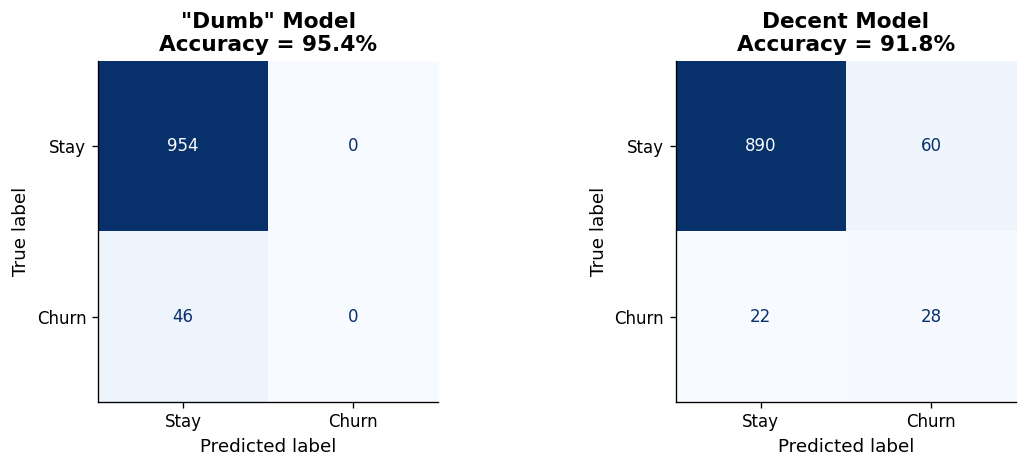

Saved → exports/confusion_matrix_comparison.png


In [16]:
# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Dumb model confusion matrix
cm_dumb = confusion_matrix(y_true_class, y_dumb)
ConfusionMatrixDisplay(cm_dumb, display_labels=['Stay','Churn']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'"Dumb" Model\nAccuracy = {accuracy_score(y_true_class, y_dumb):.1%}', 
                  fontweight='bold')

# Decent model confusion matrix
cm_decent = np.array([[tn, fp],[fn, tp]])
ConfusionMatrixDisplay(cm_decent, display_labels=['Stay','Churn']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Decent Model\nAccuracy = {accuracy_score(y_true_decent, y_decent):.1%}', 
                  fontweight='bold')

plt.tight_layout()
plt.savefig('exports/confusion_matrix_comparison.png', bbox_inches='tight')
plt.show()
print('Saved → exports/confusion_matrix_comparison.png')

**💬 The Accuracy Trap:**

The 'dumb' model scores ___ % accuracy yet is completely useless. What does the confusion matrix reveal that accuracy hides? Why is Recall the right metric for a retention team?

---
## Part 6 — ROC Curve and AUC

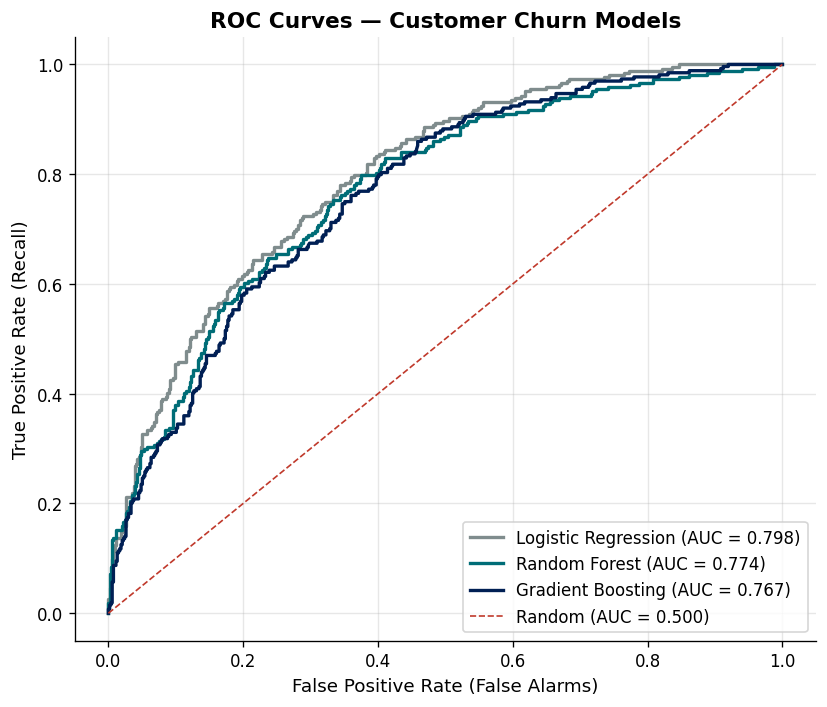

Saved → exports/roc_curves.png


In [18]:
# Rebuild the churn models quickly (reuse from Week 1 logic)
np.random.seed(SEED)
N = 4000
tenure_c       = np.random.gamma(4, 8, N).clip(1, 72)
charges_c      = np.random.normal(65, 20, N).clip(20, 120)
contract_c     = np.random.choice(['Month-to-Month','One Year','Two Year'], p=[0.55,0.25,0.20], size=N)
calls_c        = np.random.poisson(1.5, N).clip(0, 10)
usage_c        = np.random.exponential(8, N).clip(0.5, 50)
senior_c       = np.random.binomial(1, 0.16, N)
contract_risk_c = np.where(contract_c=='Month-to-Month',1.0,np.where(contract_c=='One Year',0.3,0.0))
log_odds_c     = -2.5 + 0.035*charges_c - 0.060*tenure_c + 1.4*contract_risk_c + 0.25*calls_c - 0.015*usage_c + 0.3*senior_c
churn_c        = np.random.binomial(1, 1/(1+np.exp(-log_odds_c)))

df_c = pd.DataFrame({'tenure':tenure_c.round(0).astype(int),'monthly_charges':charges_c.round(2),
    'contract_monthly':(contract_c=='Month-to-Month').astype(int),
    'contract_one_year':(contract_c=='One Year').astype(int),
    'contract_two_year':(contract_c=='Two Year').astype(int),
    'support_calls':calls_c,'data_usage_gb':usage_c.round(2),'senior_citizen':senior_c,'churn':churn_c})

FEATURES_C = ['tenure','monthly_charges','support_calls','data_usage_gb','senior_citizen',
               'contract_monthly','contract_one_year','contract_two_year']
X_c = df_c[FEATURES_C]; y_c = df_c['churn']
X_tr, X_te, y_tr, y_te = train_test_split(X_c, y_c, test_size=0.2, random_state=SEED, stratify=y_c)

models_roc = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8, random_state=SEED, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=SEED)
}

scaler_c = StandardScaler()
X_tr_s = scaler_c.fit_transform(X_tr); X_te_s = scaler_c.transform(X_te)

fig, ax = plt.subplots(figsize=(7, 6))
colors = [GRAY, TEAL, NAVY]

for (name, model), color in zip(models_roc.items(), colors):
    model.fit(X_tr_s, y_tr)
    proba = model.predict_proba(X_te_s)[:,1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], color=RED, ls='--', lw=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate (False Alarms)')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves — Customer Churn Models', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('exports/roc_curves.png', bbox_inches='tight')
plt.show()
print('Saved → exports/roc_curves.png')

**💬 ROC Curve Interpretation:**

1. If a retention team can only call 100 customers (budget constraint) and the model ranks 1,000 customers by churn probability, which metric determines how many actual churners are in their call list?
2. A manager says 'pick the model with AUC = 1.0'. Should you be excited or suspicious? Why?
3. At a false positive rate of 20%, approximately what is the true positive rate for Gradient Boosting? Use the chart.

---
## Part 7 — Prophet Forecasting

Prophet models: $y(t) = g(t) + s(t) + h(t) + \varepsilon_t$

> *If Prophet is not installed, run `pip install prophet` in your terminal.*

In [20]:
if PROPHET_AVAILABLE:
    # Prophet requires columns named 'ds' and 'y'
    prophet_train = train_ts[['ds', 'y']].copy()

    # Build holiday dataframe (US holidays + custom retail spikes)
    holidays = pd.DataFrame({
        'holiday': ['thanksgiving', 'thanksgiving', 'thanksgiving',
                    'christmas',    'christmas',    'christmas'],
        'ds': pd.to_datetime(['2021-11-22', '2022-11-21', '2023-11-20',
                              '2021-12-20', '2022-12-19', '2023-12-18']),
        'lower_window': 0,
        'upper_window': 1
    })

    # Fit Prophet
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,   # we have weekly data, not daily
        daily_seasonality=False,
        seasonality_mode='additive',
        holidays=holidays,
        changepoint_prior_scale=0.05  # controls trend flexibility
    )
    m.fit(prophet_train)
    print('Prophet model fitted successfully.')
    print(f'Training observations: {len(prophet_train)}')
else:
    print('Prophet not available — install with: pip install prophet')

08:26:20 - cmdstanpy - INFO - Chain [1] start processing
08:26:21 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted successfully.
Training observations: 156


In [22]:
if PROPHET_AVAILABLE:
    # Forecast 4 weeks ahead (plus fitted values)
    future = m.make_future_dataframe(periods=FORECAST_HORIZON, freq='W')
    forecast = m.predict(future)

    # Evaluate on test set
    prophet_preds = forecast.tail(FORECAST_HORIZON)['yhat'].values

    prophet_mae  = mean_absolute_error(test_ts['y'], prophet_preds)
    prophet_mape = mean_absolute_percentage_error(test_ts['y'], prophet_preds)
    prophet_rmse = np.sqrt(mean_squared_error(test_ts['y'], prophet_preds))

    # Compare to naive
    print('=== Forecast Comparison: Naive vs. Prophet ===')
    print(f'{"Metric":10s}  {"Naive":>12s}  {"Prophet":>12s}  {"Improvement":>12s}')
    print('-'*52)
    print(f'{"MAE":10s}  ${naive_mae:>10,.0f}  ${prophet_mae:>10,.0f}  {(naive_mae-prophet_mae)/naive_mae:>11.1%}')
    print(f'{"RMSE":10s}  ${naive_rmse:>10,.0f}  ${prophet_rmse:>10,.0f}  {(naive_rmse-prophet_rmse)/naive_rmse:>11.1%}')
    print(f'{"MAPE":10s}  {naive_mape:>11.1%}  {prophet_mape:>11.1%}  {naive_mape-prophet_mape:>10.1%} pp')

=== Forecast Comparison: Naive vs. Prophet ===
Metric             Naive       Prophet   Improvement
----------------------------------------------------
MAE         $       458  $       461        -0.9%
RMSE        $       496  $       483         2.7%
MAPE               8.2%         8.2%       -0.1% pp


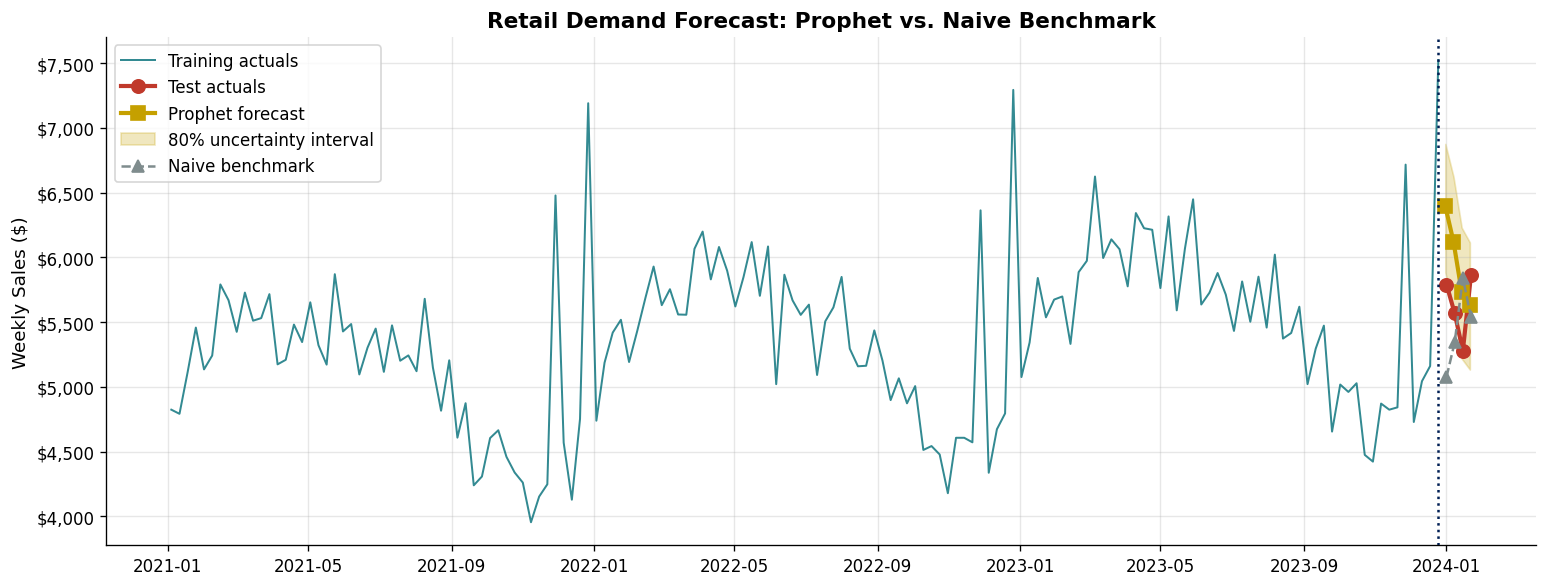

Saved → exports/prophet_forecast.png


In [24]:
if PROPHET_AVAILABLE:
    # Plot forecast with uncertainty intervals
    fig, ax = plt.subplots(figsize=(13, 5))

    # Training actuals
    ax.plot(prophet_train['ds'], prophet_train['y'],
            color=TEAL, lw=1.2, alpha=0.8, label='Training actuals')

    # Test actuals
    ax.plot(test_ts['ds'], test_ts['y'],
            color=RED, lw=2.5, marker='o', markersize=8, label='Test actuals')

    # Prophet forecast
    fc = forecast.tail(FORECAST_HORIZON)
    ax.plot(fc['ds'], fc['yhat'], color=GOLD, lw=2.5, marker='s', markersize=8, label='Prophet forecast')
    ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'],
                    color=GOLD, alpha=0.25, label='80% uncertainty interval')

    # Naive benchmark
    ax.plot(test_ts['ds'], naive_forecast, color=GRAY, lw=1.5, ls='--',
            marker='^', markersize=7, label='Naive benchmark')

    ax.axvline(train_ts['ds'].max(), color=NAVY, ls=':', lw=1.5)
    ax.set_title('Retail Demand Forecast: Prophet vs. Naive Benchmark', fontweight='bold')
    ax.set_ylabel('Weekly Sales ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('exports/prophet_forecast.png', bbox_inches='tight')
    plt.show()
    print('Saved → exports/prophet_forecast.png')

**💬 Prophet Forecast Interpretation:**

1. Does Prophet outperform the naive benchmark? By how much (MAPE)?
2. Look at the uncertainty intervals. Are they wider or narrower than you expected? What drives uncertainty in a forecast?
3. Revisit Write Your Prior Q1: Was your split strategy correct? What would happen if you shuffled?

---
## Part 8 — Prophet Components Decomposition

> This is what makes Prophet uniquely valuable for business stakeholders.

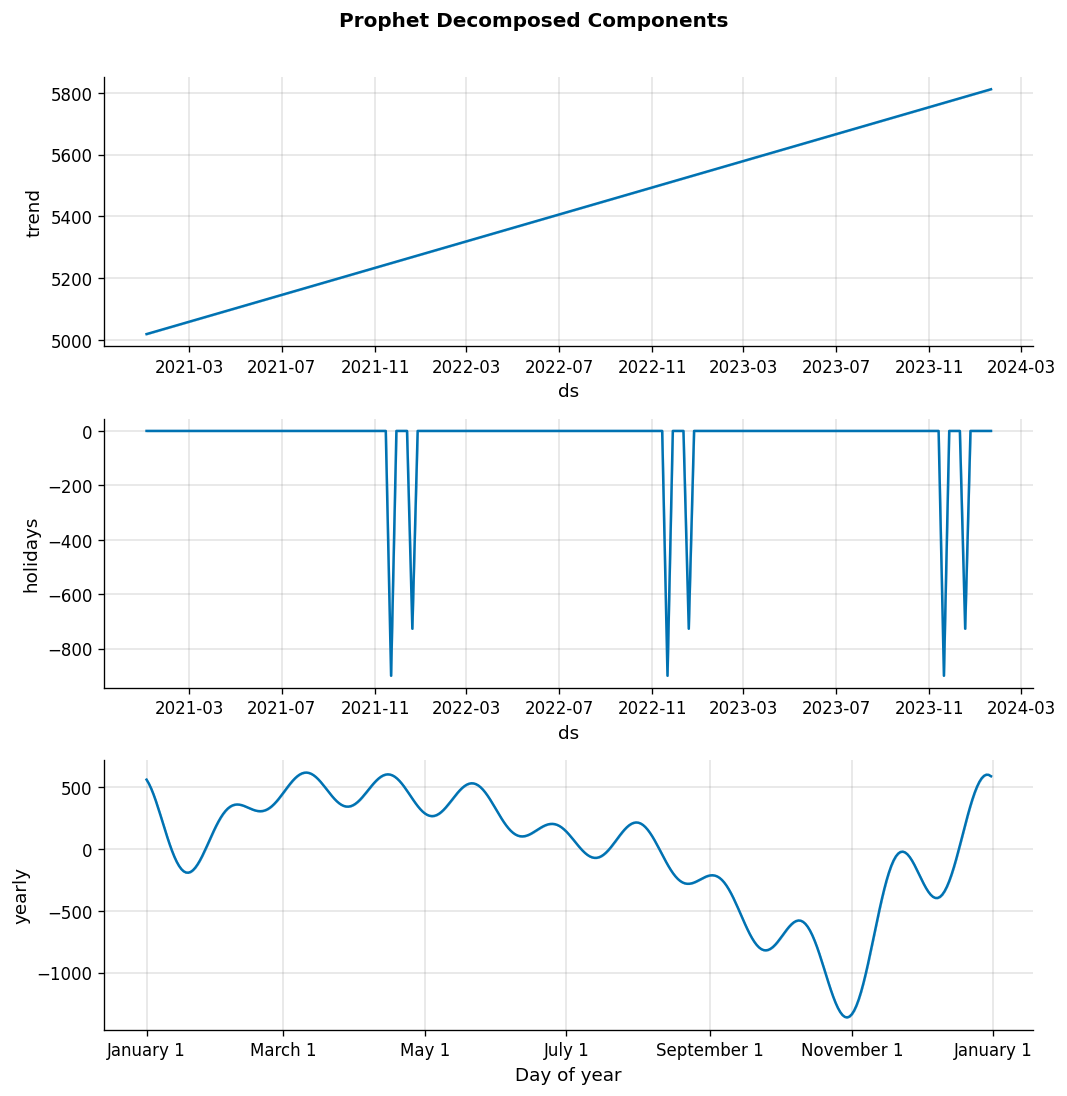

Saved → exports/prophet_components.png

The components Prophet recovered:
  - Trend: compare to our planted TRUE_TREND
  - Yearly seasonality: does it peak in Dec? (should match our sine wave)
  - Holidays: do Thanksgiving and Christmas show up clearly?


In [26]:
if PROPHET_AVAILABLE:
    fig = m.plot_components(forecast)
    fig.suptitle('Prophet Decomposed Components', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('exports/prophet_components.png', bbox_inches='tight')
    plt.show()
    print('Saved → exports/prophet_components.png')
    print()
    print('The components Prophet recovered:')
    print('  - Trend: compare to our planted TRUE_TREND')
    print('  - Yearly seasonality: does it peak in Dec? (should match our sine wave)')
    print('  - Holidays: do Thanksgiving and Christmas show up clearly?')

**💬 Component Recovery:**

Compare Prophet's recovered components to the planted truth in Part 1:
1. Does the trend direction match (upward)?
2. Does the seasonality peak in December as planted?
3. Are the holiday effects visible? How large are they relative to the baseline?
4. What would you tell a business manager about *why* sales are higher in Q4?

---
## Part 9 — Break the Estimator: Time Leakage

What happens when you shuffle time series data before splitting?

In [28]:
# Build lag features for ML approach
ts_ml = train_ts[['ds','y']].copy()
ts_ml['lag_1']  = ts_ml['y'].shift(1)
ts_ml['lag_4']  = ts_ml['y'].shift(4)
ts_ml['lag_52'] = ts_ml['y'].shift(52)
ts_ml['roll_4'] = ts_ml['y'].shift(1).rolling(4).mean()
ts_ml['month']  = ts_ml['ds'].dt.month
ts_ml['week']   = ts_ml['ds'].dt.isocalendar().week.astype(int)
ts_ml = ts_ml.dropna()

X_ts = ts_ml[['lag_1','lag_4','lag_52','roll_4','month','week']]
y_ts = ts_ml['y']

from sklearn.ensemble import GradientBoostingRegressor

# ✅ CORRECT: chronological split
split_idx = int(len(X_ts) * 0.80)
X_ts_tr, X_ts_te = X_ts.iloc[:split_idx], X_ts.iloc[split_idx:]
y_ts_tr, y_ts_te = y_ts.iloc[:split_idx], y_ts.iloc[split_idx:]

gb_ts = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=SEED)
gb_ts.fit(X_ts_tr, y_ts_tr)
mape_correct = mean_absolute_percentage_error(y_ts_te, gb_ts.predict(X_ts_te))

# ❌ WRONG: random shuffle (leaks future data into training)
X_ts_tr_sh, X_ts_te_sh, y_ts_tr_sh, y_ts_te_sh = train_test_split(
    X_ts, y_ts, test_size=0.20, random_state=SEED)  # shuffled!

gb_ts_sh = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=SEED)
gb_ts_sh.fit(X_ts_tr_sh, y_ts_tr_sh)
mape_leaked = mean_absolute_percentage_error(y_ts_te_sh, gb_ts_sh.predict(X_ts_te_sh))

print('=== Time Leakage Demo ===')
print(f'❌ Random shuffle (leakage):    MAPE = {mape_leaked:.1%}')
print(f'✅ Chronological split (correct): MAPE = {mape_correct:.1%}')
print(f'\nLeakage inflated performance by {mape_correct - mape_leaked:.1%} MAPE points')
print('(The shuffled model looks better because it saw future data during training!)')

=== Time Leakage Demo ===
❌ Random shuffle (leakage):    MAPE = 4.8%
✅ Chronological split (correct): MAPE = 6.0%

Leakage inflated performance by 1.2% MAPE points
(The shuffled model looks better because it saw future data during training!)


**💬 Time Leakage:**

Explain in plain language *why* the randomly shuffled model appears to perform better, but would fail in production. What does it 'see' during training that it would never have access to in the real world?

---
---
## ⭐ Write Your Prior — Class 4

> **Answer before running any Class 4 code:**

1. A hospital uses an ML model to allocate nursing resources. The model was trained on historical data where certain zip codes received fewer nurses. What type of bias might this model perpetuate? What would you check?

2. A venture capital firm uses an ML model trained on historical investment decisions to screen pitches. The model gives high scores to companies with founders who graduated from certain elite universities. Is this model doing its job well? What problem might arise?

3. Your Gradient Boosting churn model has AUC = 0.91. A manager asks: 'Which features should we fix to reduce churn?' Is AUC the right tool to answer that question? What tool would you use instead?

**Your answers (write before running any Class 4 code):**

1. 

2. 

3. 

---
## Part 10 — Prediction vs. Causation: Decision Matrix

In [ ]:
# A structured reflection on the prediction vs. causation distinction
# (no code to run — answer in the cell below)

questions = [
    ('Will this customer default on their loan next month?',
     'Prediction — no policy action needed, just rank-order risk'),
    ('Did our new loyalty program cause more repeat purchases?',
     'Causal — need DiD or A/B test to isolate the effect'),
    ('How many units will we sell next quarter?',
     'Prediction (forecasting) — ML or Prophet'),
    ('Does the minimum wage increase reduce employment?',
     'Causal — need quasi-experimental design (DiD)'),
    ('Which customers are most likely to respond to our email?',
     'Prediction — rank by propensity score'),
    ('Did the new checkout UX increase conversion rates?',
     'Causal — A/B test eliminates confounding'),
]

print('=== Prediction vs. Causation Drill ===')
print(f'{"Business Question":<55}  Answer')
print('='*95)
for q, a in questions:
    print(f'  {q:<53}  {a}')
    print()

**💬 Your Turn — Add 2 Examples:**

Write one business question that is a **prediction task** and one that is a **causal task** from an industry you are interested in. State which tool you would use for each.

**Prediction task:** 

**Causal task:** 

---
## Part 11 — SHAP Explainability

SHAP (SHapley Additive exPlanations) answers: *how much did each feature contribute to this specific prediction?*

In [ ]:
if SHAP_AVAILABLE:
    # Use the gradient boosting model from Part 6
    gb_model = models_roc['Gradient Boosting']

    # SHAP TreeExplainer (fast for tree-based models)
    explainer = shap.TreeExplainer(gb_model)
    X_te_sample = pd.DataFrame(X_te_s[:200], columns=FEATURES_C)  # use 200 rows for speed
    shap_values = explainer.shap_values(X_te_sample)

    print('SHAP values computed for 200 test customers.')
    print(f'Shape of SHAP array: {shap_values.shape}  (rows × features)')
    print()
    print('Mean |SHAP| by feature (global importance):')
    mean_shap = pd.Series(np.abs(shap_values).mean(axis=0),
                           index=FEATURES_C).sort_values(ascending=False)
    for feat, val in mean_shap.items():
        print(f'  {feat:25s}  {val:.4f}')
else:
    print('SHAP not installed. Install with: pip install shap')

In [ ]:
if SHAP_AVAILABLE:
    # Global: beeswarm summary plot
    plt.figure(figsize=(9, 5))
    shap.summary_plot(shap_values, X_te_sample, plot_type='bar',
                      color=NAVY, show=False)
    plt.title('SHAP Feature Importance — Global (mean |SHAP|)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('exports/shap_global_importance.png', bbox_inches='tight')
    plt.show()
    print('Saved → exports/shap_global_importance.png')

In [ ]:
if SHAP_AVAILABLE:
    # Local: waterfall plot for one specific customer
    # Find a high-risk customer (predicted churn prob > 0.7)
    proba_te = gb_model.predict_proba(X_te_s[:200])[:,1]
    high_risk_idx = np.argmax(proba_te)   # customer with highest predicted churn probability

    print(f'Explaining Customer #{high_risk_idx} — Predicted churn probability: {proba_te[high_risk_idx]:.1%}')
    print('Customer profile:')
    profile = pd.Series(X_te_sample.iloc[high_risk_idx], name='Value')
    print(profile.to_string())

    # SHAP for this customer
    customer_shap = shap_values[high_risk_idx]
    contribution = pd.Series(customer_shap, index=FEATURES_C).sort_values()

    fig, ax = plt.subplots(figsize=(9, 5))
    colors_shap = [RED if v > 0 else TEAL for v in contribution]
    contribution.plot(kind='barh', ax=ax, color=colors_shap)
    ax.axvline(0, color=GRAY, lw=0.8)
    ax.set_title(f'SHAP Waterfall — Customer #{high_risk_idx}\n'
                 f'Predicted churn prob = {proba_te[high_risk_idx]:.1%}',
                 fontweight='bold')
    ax.set_xlabel('SHAP value (contribution to log-odds of churn)')
    ax.text(0.98, 0.02, 'Red = increases churn risk\nTeal = decreases churn risk',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=9, color=GRAY,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.tight_layout()
    plt.savefig('exports/shap_local_waterfall.png', bbox_inches='tight')
    plt.show()
    print('Saved → exports/shap_local_waterfall.png')

**💬 SHAP Interpretation:**

For the high-risk customer:
1. What is the single largest risk factor driving their churn prediction?
2. Is there a protective factor (a feature reducing churn risk)?
3. If you were writing the retention offer for this customer, what would you emphasize? (Think like a business analyst, not a statistician.)
4. Can we use the SHAP value for `monthly_charges` to conclude that *lowering* that customer's bill *will cause* them to stay? Why or why not?

---
## Part 12 — ML Fairness: Slice Error Metrics by Group

In [ ]:
# Evaluate model performance separately for senior vs. non-senior citizens
gb_model_final = models_roc['Gradient Boosting']
X_te_df = pd.DataFrame(X_te_s, columns=FEATURES_C)
y_te_arr = y_te.values

proba_all = gb_model_final.predict_proba(X_te_s)[:,1]
pred_all  = gb_model_final.predict(X_te_s)

# Slice by senior citizen
senior_mask   = X_te_df['senior_citizen'] == 1
nonsenior_mask = ~senior_mask

print('=== Fairness Audit: AUC by Senior Citizen Status ===')
print()
for label, mask in [('Non-Senior Citizens', nonsenior_mask), ('Senior Citizens', senior_mask)]:
    n     = mask.sum()
    auc   = roc_auc_score(y_te_arr[mask], proba_all[mask])
    rec   = recall_score(y_te_arr[mask], pred_all[mask])
    prec  = precision_score(y_te_arr[mask], pred_all[mask], zero_division=0)
    churn = y_te_arr[mask].mean()
    print(f'{label} (n={n:,}):')
    print(f'  Churn rate: {churn:.1%}')
    print(f'  AUC:        {auc:.4f}')
    print(f'  Recall:     {rec:.1%}   ← % of actual churners caught')
    print(f'  Precision:  {prec:.1%}   ← % of flagged customers who actually churn')
    print()

**💬 Fairness Discussion:**

1. Is the AUC similar or different across groups? What does a significant gap imply for deployment?
2. If Recall is lower for senior citizens, what does that mean for a retention campaign targeting seniors?
3. The planted DGP includes a `senior_citizen` coefficient of +0.30. Does including this feature raise ethical concerns? How would you handle this if you were deploying the model at a telecom?
4. Name one real-world case discussed in class where a deployed ML model caused measurable harm due to biased training data.

---
## Part 13 — The Course Toolkit: Matching Tools to Questions

> **Final synthesis exercise.** For each scenario, identify the right tool from the course.

In [ ]:
# Fill in the 'Right Tool' column in the cell below
scenarios = [
    'Will this job applicant accept our offer?',
    'Did our employee training program increase productivity?',
    'How much will we sell next quarter by product category?',
    'Did the new pricing strategy cause us to lose market share?',
    'Which customers are most similar (for segmentation)?',
    'Does higher education cause higher wages?',
    'What drives customer sentiment in our reviews?',
    'Is this credit card transaction fraudulent?',
]

for i, s in enumerate(scenarios, 1):
    print(f'{i}. {s}')

**Your tool mapping (fill in all 8):**

For each scenario, write the appropriate tool from: *ML (specify type), DiD, A/B Test, OLS/Regression, NLP/Sentiment, Clustering/Unsupervised, Prophet/Forecasting*

1. Tool: ___   Reason: ___
2. Tool: ___   Reason: ___
3. Tool: ___   Reason: ___
4. Tool: ___   Reason: ___
5. Tool: ___   Reason: ___
6. Tool: ___   Reason: ___
7. Tool: ___   Reason: ___
8. Tool: ___   Reason: ___

---
## Part 14 — Executive Summary: Your ML Pipeline

> **Write a 5-sentence business brief** summarizing what you built over Weeks 1–2, as if presenting to a non-technical VP of Marketing at the telecom company.

**Your executive summary:**

*(Sentence 1: What problem did you solve?)* 

*(Sentence 2: What data did you use and how did you prepare it?)* 

*(Sentence 3: What model performed best and by what metric?)* 

*(Sentence 4: What are the top 2–3 drivers of churn, according to SHAP?)* 

*(Sentence 5: What action should the retention team take, and what is the estimated monthly value?)* 

---
## Part 15 — Revisit Your Priors (Class 4)

> Look back at your Class 4 Write Your Prior answers.

**Class 4 Prior Revisit:**

- Q1 (hospital bias): Based on Part 12, what type of audit would catch this problem?
- Q2 (VC model): What is the name for the type of bias where historical decisions are encoded into a model's predictions? (Feedback loop / Historical bias)
- Q3 (SHAP vs. AUC): Were you right? What tool did we use to explain individual predictions?

---
## Final Reflection

> Answer in 3–5 sentences (this counts toward participation).

**Looking back across the entire course (Weeks 1–17):**

1. What is the single most important distinction you have learned this semester? (Think: prediction vs. causation, in-sample vs. out-of-sample, or another key idea.)

2. Name one business decision in your future career where you would use a **causal inference tool** (DiD, A/B test) rather than an ML model. Explain why.

3. What question from your final project could you answer better now than you could at the start of the semester?

**Your answer:**

---
## Submission Checklist

Before submitting to Blackboard:

- [ ] Student name is filled in at the top
- [ ] All cells have been run (no empty output cells)
- [ ] All three Write Your Prior cells are filled in (Classes 3 and 4)
- [ ] All Interpretation and Discussion cells are answered
- [ ] Part 13 tool mapping is complete (all 8 scenarios)
- [ ] Executive Summary (Part 14) is written
- [ ] Final Reflection is written
- [ ] `exports/` contains: `retail_ts_decomposition.png`, `ts_train_test_split.png`, `confusion_matrix_comparison.png`, `roc_curves.png`, `prophet_forecast.png`, `prophet_components.png`, `shap_global_importance.png`, `shap_local_waterfall.png`
- [ ] Notebook submitted as `.ipynb`

**Point allocation:**

| Section | Points |
|---|---|
| Write Your Prior — Class 3 (attempted before running) | 10 |
| Write Your Prior — Class 4 (attempted before running) | 10 |
| Interpretation cells — Class 3 (5 × 4 pts each) | 20 |
| SHAP Interpretation (Part 11) | 10 |
| Fairness Discussion (Part 12) | 10 |
| Tool Mapping exercise (Part 13) | 10 |
| Executive Summary (Part 14) | 10 |
| Prior Revisit + Final Reflection | 10 |
| Code runs without errors, all exports saved | 10 |
| **Total** | **100** |